<a href="https://colab.research.google.com/github/andreanchalvari/SkripsiAndre/blob/main/64TransformerFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Setup dan Import Library

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import glob
import rasterio
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')
from scipy.ndimage import binary_closing, binary_opening
import tifffile

# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Konfigurasi untuk menghemat RAM
tf.config.optimizer.set_jit(True)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# Batasi penggunaan GPU memory
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

# Fungsi untuk membersihkan memory
def clear_memory():
    gc.collect()
    tf.keras.backend.clear_session()

Mounted at /content/drive


# Section 2: Konfigurasi dan Path

In [ ]:
BASE_PATH = '/content/drive/MyDrive/landsat_dataset_new'

# Patch configuration
PATCH_SIZE = 64

# Training configuration
BATCH_SIZE = 16
EPOCHS = 5
BUFFER_SIZE = 50

# Data configuration
CHANNELS = 13

TRAIN_SPLIT = 0.7
TEST_SPLIT  = 0.3

# Cropping configuration
# Dari 7761 x 7621 → 7744 x 7616
CROP_HEIGHT = 7744
CROP_WIDTH  = 7616

# PATH OUTPUT
MODEL_SAVE_PATH = '/content/drive/MyDrive/model_transformer_64'
RESULTS_PATH = '/content/drive/MyDrive/hasil_transformer_64'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# BAND CONFIGURATION
BAND_PATTERNS = {
    'B1': '*SR_B1.TIF',
    'B2': '*SR_B2.TIF',
    'B3': '*SR_B3.TIF',
    'B4': '*SR_B4.TIF',
    'B5': '*SR_B5.TIF',
    'B6': '*SR_B6.TIF',
    'B7': '*SR_B7.TIF',
    'B10': '*ST_B10.TIF',
    'QA': '*QA_PIXEL.TIF'
}

BAND_ORDER = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B10', 'QA']

# Section 3: Load Citra Landsat

In [ ]:
import os
import glob
import gc
import numpy as np
import rasterio

from scipy.ndimage import uniform_filter
from skimage.filters.rank import entropy
from skimage.morphology import disk
from skimage.util import img_as_ubyte
from scipy.ndimage import sobel

# DATA PROCESSOR CLASS
class LandsatDataProcessor:

    def __init__(
        self,
        patch_size=64,
        crop_height=7744,
        crop_width=7616
    ):

        self.patch_size = patch_size
        self.crop_height = crop_height
        self.crop_width = crop_width


    # LOAD SEMUA BAND
    def load_all_bands(self, scene_folder):

        bands_data = {}

        for band_name, pattern in BAND_PATTERNS.items():

            file_path = glob.glob(
                os.path.join(scene_folder, pattern)
            )

            if not file_path:
                print(f"❌ Band {band_name} tidak ditemukan")
                return None

            with rasterio.open(file_path[0]) as src:

                band = src.read(1).astype(np.float32)

                # crop
                band = band[
                    :self.crop_height,
                    :self.crop_width
                ]

                bands_data[band_name] = band

        return bands_data


    # PREPROCESS BAND
    def preprocess_bands(self, bands_data):

        processed_bands = []
        band_dict = {}

        # SR BANDS B1-B7
        for band_name in [
            'B1','B2','B3',
            'B4','B5','B6','B7'
        ]:

            band = bands_data[band_name]

            # scaling Landsat Collection 2
            scaled = band * 0.0000275 - 0.2

            clipped = np.clip(
                scaled,
                0,
                1
            )

            p1 = np.percentile(clipped, 1)
            p99 = np.percentile(clipped, 99)

            normalized = (
                clipped - p1
            ) / (
                p99 - p1 + 1e-7
            )

            normalized = np.clip(
                normalized,
                0,
                1
            )

            processed_bands.append(normalized)

            band_dict[band_name] = normalized

            del band
            del scaled
            del clipped

        # THERMAL B10
        b10 = bands_data["B10"]

        scaled_b10 = (
            b10 * 0.00341802
        ) + 149.0

        normalized_b10 = (
            scaled_b10 - 200
        ) / 150

        normalized_b10 = np.clip(
            normalized_b10,
            0,
            1
        )

        processed_bands.append(
            normalized_b10
        )

        band_dict["B10"] = normalized_b10

        del b10
        del scaled_b10

        # REFERENSI BAND
        B2 = band_dict["B2"]
        B3 = band_dict["B3"]
        B4 = band_dict["B4"]
        B5 = band_dict["B5"]
        B6 = band_dict["B6"]

        # NIR / SWIR RATIO
        nir_swir_ratio = (
            B5 / (B6 + 1e-6)
        )

        # BRIGHTNESS
        brightness = (
            B2 + B3 + B4
        ) / 3

        # SOBEL GRADIENT MAGNITUDE
        # Hitung gradien arah horizontal
        grad_x = sobel(
            brightness,
            axis=1,
            mode="reflect"
        )

        # Hitung gradien arah vertikal
        grad_y = sobel(
            brightness,
            axis=0,
            mode="reflect"
        )

        # Gradient Magnitude
        gradient_magnitude = np.sqrt(
            grad_x**2 +
            grad_y**2
        ).astype(np.float32)

        # Normalisasi ke 0-1
        gradient_magnitude = (
            gradient_magnitude -
            gradient_magnitude.min()
        ) / (
            gradient_magnitude.max() -
            gradient_magnitude.min() +
            1e-6
        )

        del grad_x
        del grad_y

        # LOCAL ENTROPY
        entropy_input = img_as_ubyte(brightness)

        local_entropy = entropy(
            entropy_input,
            disk(2)          # window 5x5
        ).astype(np.float32)

        # normalisasi 0-1
        local_entropy = (
            local_entropy -
            local_entropy.min()
        ) / (
            local_entropy.max() -
            local_entropy.min() +
            1e-6
        )

        del entropy_input

        # TAMBAHKAN CHANNEL
        processed_bands.extend([
            nir_swir_ratio,
            brightness,
            local_entropy,
            gradient_magnitude,
        ])


        # STACK
        stacked_image = np.stack(
            processed_bands,
            axis=-1
        ).astype(np.float32)

        print(
            "Total channel:",
            stacked_image.shape[-1]
        )

        gc.collect()

        return stacked_image


# LOAD FULL SCENE
def load_full_scene(base_path):

    processor = LandsatDataProcessor(
        PATCH_SIZE,
        CROP_HEIGHT,
        CROP_WIDTH
    )

    scenes = []


    # CARI SCENE
    for item in os.listdir(base_path):

        item_path = os.path.join(
            base_path,
            item
        )

        if os.path.isdir(item_path):

            tif_files = [
                f for f in os.listdir(item_path)
                if f.endswith(".TIF")
            ]

            if len(tif_files) >= 9:
                scenes.append(item_path)

    # fallback
    if not scenes:

        tif_files = [
            f for f in os.listdir(base_path)
            if f.endswith(".TIF")
        ]

        if len(tif_files) >= 9:
            scenes = [base_path]

    if not scenes:

        print("❌ Scene tidak ditemukan")

        return None, None

    scene_path = scenes[0]

    print(
        f"\n🔥 Loading scene: "
        f"{os.path.basename(scene_path)}"
    )


    # LOAD BAND
    bands_data = processor.load_all_bands(
        scene_path
    )

    if bands_data is None:

        print("❌ Band tidak lengkap")

        return None, None


    # PREPROCESS
    full_scene = processor.preprocess_bands(
        bands_data
    )

    qa_full = bands_data["QA"]


    # INFO
    print("\n=== INFO FULL SCENE ===")

    print(
        "Shape scene :",
        full_scene.shape
    )

    print(
        "Shape QA    :",
        qa_full.shape
    )

    print(
        f"Memory scene: "
        f"{full_scene.nbytes/1024**2:.2f} MB"
    )

    return full_scene, qa_full

# RUN
print("Loading Landsat full scene...")

full_scene, qa_full = load_full_scene(
    BASE_PATH
)

Loading Landsat full scene...

🔥 Loading scene: landsat_dataset_new
Total channel: 12

=== INFO FULL SCENE ===
Shape scene : (7744, 7616, 12)
Shape QA    : (7744, 7616)
Memory scene: 2699.81 MB


PERBANDINGAN CITRA ASLI DAN CITRA SETELAH CROP

=== OVERLAY CROPPING ===
Original : 7771 7641


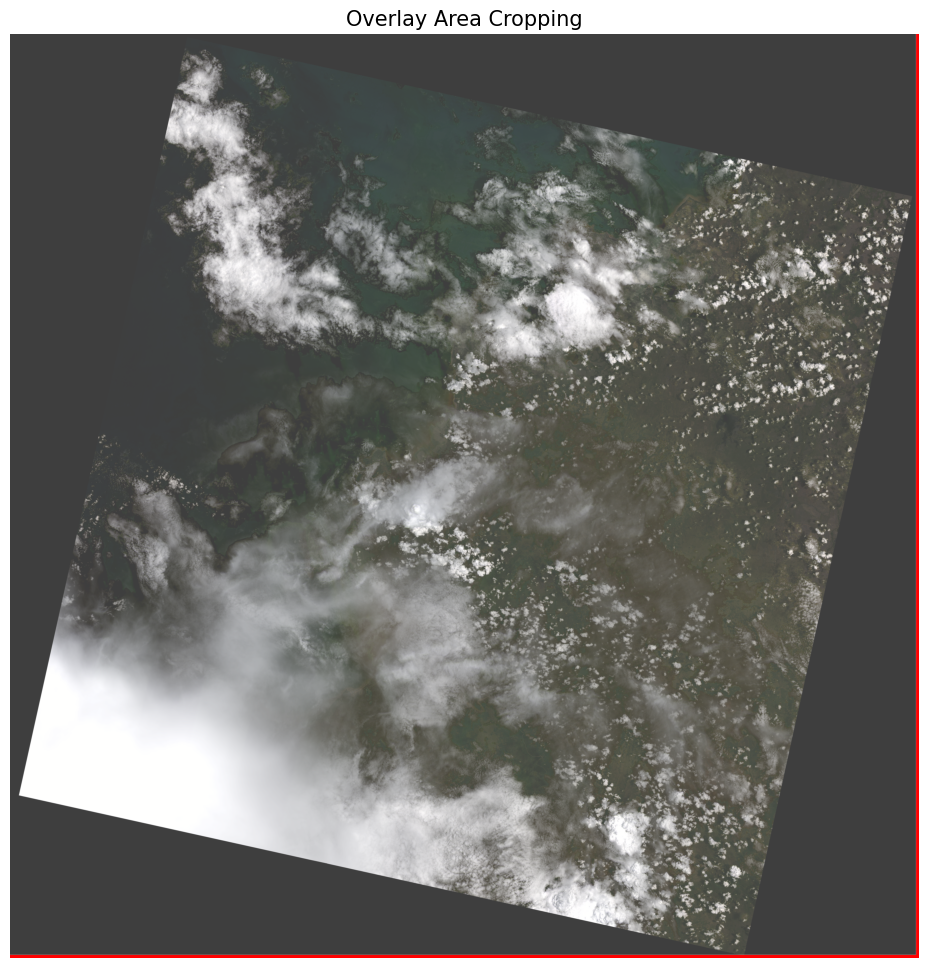

In [ ]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("=== OVERLAY CROPPING ===")

BASE_PATH = "/content/drive/MyDrive/landsat_dataset_new"

# UKURAN
CROP_HEIGHT = 7744
CROP_WIDTH  = 7616

# CARI SCENE
scene_path = None

for item in os.listdir(BASE_PATH):

    item_path = os.path.join(BASE_PATH, item)

    if os.path.isdir(item_path):

        if len(glob.glob(os.path.join(item_path, "*SR_B4.TIF"))) > 0:
            scene_path = item_path
            break

if scene_path is None:
    scene_path = BASE_PATH

# LOAD RGB
bands = []

for band in ["B4","B3","B2"]:

    file = glob.glob(
        os.path.join(scene_path,f"*{band}.TIF")
    )[0]

    with rasterio.open(file) as src:

        img = src.read(1).astype(np.float32)

        img = img * 0.0000275 - 0.2
        img = np.clip(img,0,1)

        p2 = np.percentile(img,2)
        p98 = np.percentile(img,98)

        img = np.clip(
            (img-p2)/(p98-p2+1e-6),
            0,
            1
        )

        bands.append(img)

rgb = np.dstack(bands)

H, W = rgb.shape[:2]

print("Original :", H, W)

# OVERLAY RGBA
overlay = np.zeros((H, W, 4), dtype=np.float32)

# AREA YANG DIPERTAHANKAN (PUTIH TRANSPARAN)
overlay[:CROP_HEIGHT, :CROP_WIDTH, 0] = 1
overlay[:CROP_HEIGHT, :CROP_WIDTH, 1] = 1
overlay[:CROP_HEIGHT, :CROP_WIDTH, 2] = 1
overlay[:CROP_HEIGHT, :CROP_WIDTH, 3] = 0.25

# AREA YANG DIPOTONG (MERAH SOLID)
overlay[CROP_HEIGHT:, :, 0] = 1
overlay[CROP_HEIGHT:, :, 3] = 1.0

overlay[:, CROP_WIDTH:, 0] = 1
overlay[:, CROP_WIDTH:, 3] = 1.0

# VISUALISASI
plt.figure(figsize=(12,12))

plt.imshow(rgb)

plt.imshow(overlay)

plt.title(
    "Overlay Area Cropping",
    fontsize=15
)

plt.axis("off")

plt.show()

# Section 4: Load Hasil Prediksi GAN

In [ ]:
import numpy as np

print("Loading GAN binary cloud mask...")

gan_mask = np.load("/content/drive/MyDrive/hasil_prediksi_awan_balance_64x64/gan_mask64.npy")

print("Shape GAN mask:", gan_mask.shape)
print("Tipe data:", gan_mask.dtype)

# pastikan binary
gan_mask = (gan_mask > 0).astype(np.uint8)

print("Unique value:", np.unique(gan_mask))


Loading GAN binary cloud mask...
Shape GAN mask: (7744, 7616)
Tipe data: uint8
Unique value: [0 1]


In [ ]:
print("Scene shape :", full_scene.shape[:2])
print("GAN shape   :", gan_mask.shape)

Scene shape : (7744, 7616)
GAN shape   : (7744, 7616)


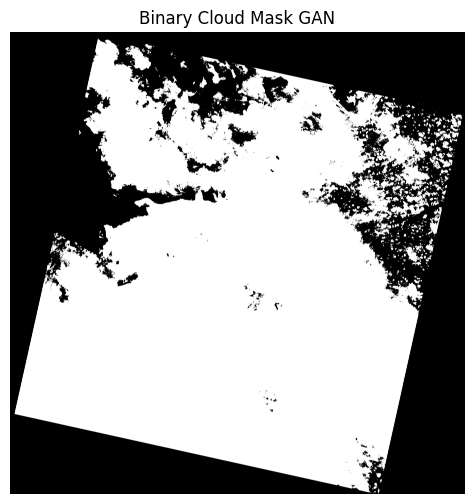

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(gan_mask, cmap="gray")
plt.title("Binary Cloud Mask GAN")
plt.axis("off")
plt.show()

In [ ]:
# STATISTIK HASIL PREDIKSI GAN
cloud_pixel = np.sum(gan_mask == 1)
noncloud_pixel = np.sum(gan_mask == 0)

total_pixel = gan_mask.size

cloud_percentage = (cloud_pixel / total_pixel) * 100
noncloud_percentage = (noncloud_pixel / total_pixel) * 100

print("\n========== STATISTIK HASIL PREDIKSI GAN ==========")
print(f"Total Piksel         : {total_pixel:,}")
print(f"Piksel Cloud         : {cloud_pixel:,}")
print(f"Piksel Non-Cloud     : {noncloud_pixel:,}")
print(f"Persentase Cloud     : {cloud_percentage:.2f}%")
print(f"Persentase Non-Cloud : {noncloud_percentage:.2f}%")


========== STATISTIK HASIL PREDIKSI GAN ==========
Total Piksel         : 58,978,304
Piksel Cloud         : 33,502,891
Piksel Non-Cloud     : 25,475,413
Persentase Cloud     : 56.81%
Persentase Non-Cloud : 43.19%


# Section 5 : Cirrus Mask

BUAT CIRRUS MASK

=== BUILD CIRRUS MASK (GAN ∩ QA_PIXEL) ===
GAN cloud pixel : 33502891
QA Cirrus pixel : 23101336
Final Cirrus pixel : 23092024

=== STATISTIK ===
GAN Cloud      : 33502891
QA Cirrus      : 23101336
Final Cirrus   : 23092024
Persentase Cirrus terhadap Cloud : 68.93%

✔ cirrus_mask_final_64.npy tersimpan


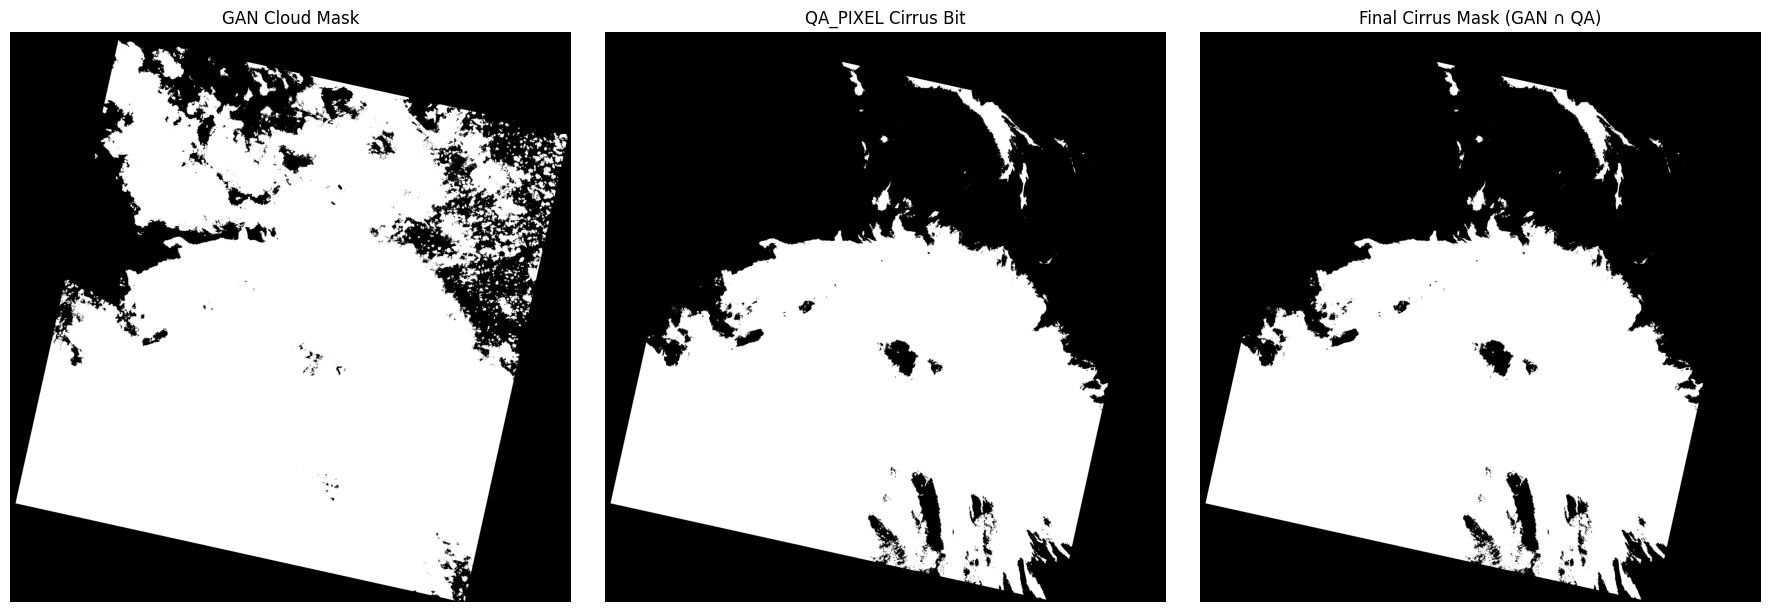

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("=== BUILD CIRRUS MASK (GAN ∩ QA_PIXEL) ===")

# GAN MASK
gan_mask = (gan_mask > 0).astype(np.uint8)

print("GAN cloud pixel :", np.sum(gan_mask))


# EKSTRAK CIRRUS DARI QA_PIXEL (Bit-2 = Cirrus)
qa_uint = qa_full.astype(np.uint16)

cirrus_bit = ((qa_uint >> 2) & 1).astype(np.uint8)

print("QA Cirrus pixel :", np.sum(cirrus_bit))

# IRISAN GAN DAN CIRRUS
cirrus_mask_final = np.logical_and(
    gan_mask == 1,
    cirrus_bit == 1
).astype(np.uint8)

print("Final Cirrus pixel :", np.sum(cirrus_mask_final))


# INFORMASI
print("\n=== STATISTIK ===")

print(
    "GAN Cloud      :",
    np.sum(gan_mask)
)

print(
    "QA Cirrus      :",
    np.sum(cirrus_bit)
)

print(
    "Final Cirrus   :",
    np.sum(cirrus_mask_final)
)

print(
    "Persentase Cirrus terhadap Cloud : "
    f"{100*np.sum(cirrus_mask_final)/(np.sum(gan_mask)+1e-6):.2f}%"
)


# SIMPAN
np.save(
    "/content/drive/MyDrive/hasil_transformer_64/cirrus_mask_final_64.npy",
    cirrus_mask_final
)

print("\n✔ cirrus_mask_final_64.npy tersimpan")


# VISUALISASI
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(
    gan_mask,
    cmap="gray"
)

ax[0].set_title("GAN Cloud Mask")
ax[0].axis("off")


ax[1].imshow(
    cirrus_bit,
    cmap="gray"
)

ax[1].set_title("QA_PIXEL Cirrus Bit")
ax[1].axis("off")

ax[2].imshow(
    cirrus_mask_final,
    cmap="gray"
)

ax[2].set_title("Final Cirrus Mask (GAN ∩ QA)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

BUAT NON-CIRRUS MASK

=== BUILD NON-CIRRUS CLOUD MASK ===
Cloud pixel        : 33502891
Cirrus pixel       : 23092024
Non-Cirrus pixel   : 10410867
Validasi : 33502891
GAN Cloud: 33502891
✔ non_cirrus_mask_64.npy tersimpan


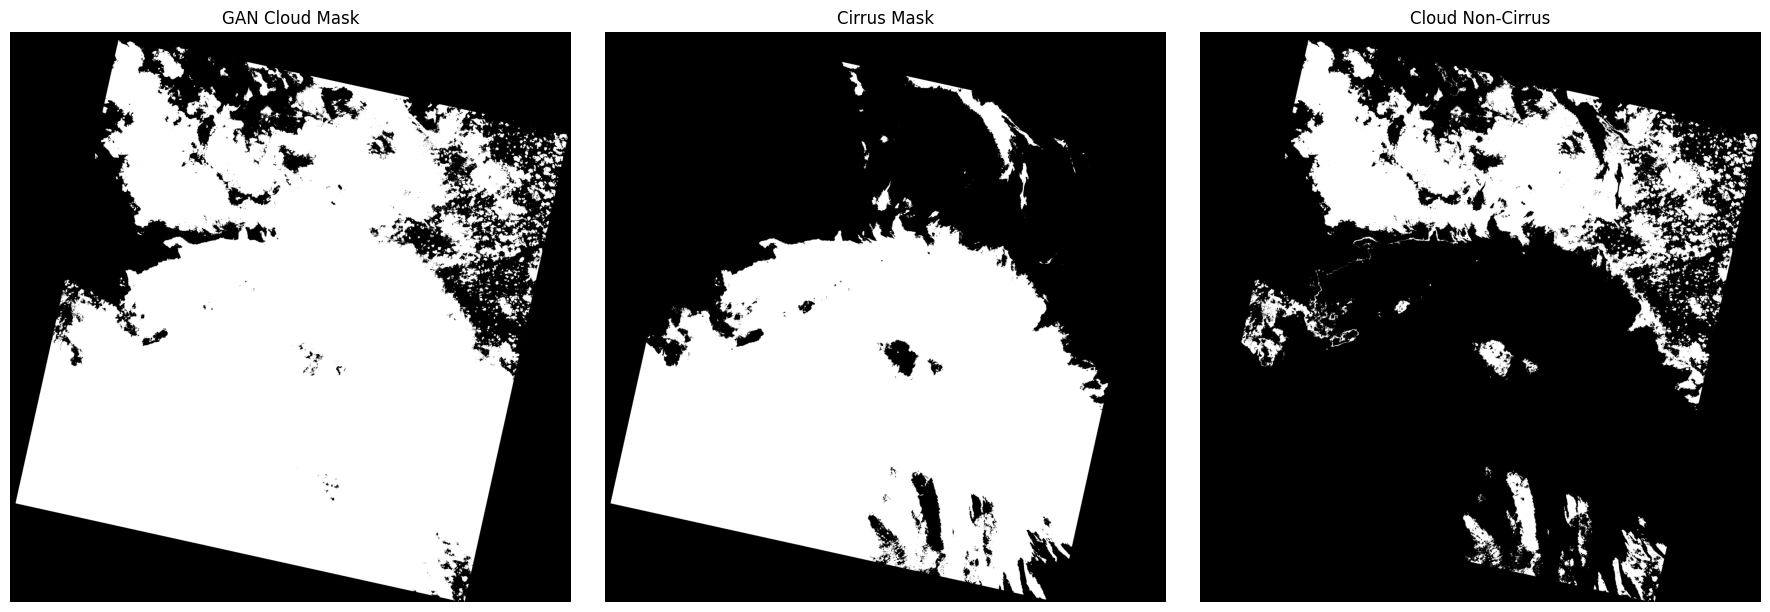

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("=== BUILD NON-CIRRUS CLOUD MASK ===")

# NON CIRRUS CLOUD
non_cirrus_mask = np.logical_and(
    gan_mask == 1,
    cirrus_mask_final == 0
).astype(np.uint8)

print("Cloud pixel        :", np.sum(gan_mask))
print("Cirrus pixel       :", np.sum(cirrus_mask_final))
print("Non-Cirrus pixel   :", np.sum(non_cirrus_mask))

print(
    "Validasi :",
    np.sum(cirrus_mask_final) +
    np.sum(non_cirrus_mask)
)

print(
    "GAN Cloud:",
    np.sum(gan_mask)
)

# SIMPAN
np.save(
    "/content/drive/MyDrive/hasil_transformer_64/non_cirrus_mask_64.npy",
    non_cirrus_mask
)

print("✔ non_cirrus_mask_64.npy tersimpan")

# VISUALISASI
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(
    gan_mask,
    cmap="gray"
)
ax[0].set_title("GAN Cloud Mask")
ax[0].axis("off")

ax[1].imshow(
    cirrus_mask_final,
    cmap="gray"
)
ax[1].set_title("Cirrus Mask")
ax[1].axis("off")

ax[2].imshow(
    non_cirrus_mask,
    cmap="gray"
)
ax[2].set_title("Cloud Non-Cirrus")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("=== BUILD FULL CIRRUS MASK ===")

# QA menjadi uint16
qa_uint = qa_full.astype(np.uint16)

# Bit 2 = Cirrus
cirrus_bit = ((qa_uint >> 2) & 1).astype(np.uint8)

# Irisan dengan GAN
cirrus_full = np.logical_and(
    gan_mask == 1,
    cirrus_bit == 1
).astype(np.uint8)

print("Shape :", cirrus_full.shape)

print("Cirrus pixel :", np.sum(cirrus_full))

=== BUILD FULL CIRRUS MASK ===
Shape : (7744, 7616)
Cirrus pixel : 23092024


# Section 6: Patch Creation

In [ ]:
import numpy as np

print("=== PATCH CREATION + COORDINATE ===")

# PATCH SIZE
PATCH_SIZE = 64
ps = PATCH_SIZE

# SCENE INFO
H, W, C = full_scene.shape

print("Scene shape :", full_scene.shape)
print("GAN shape   :", gan_mask.shape)
print("Cirrus shape:", cirrus_mask_final.shape)
print("NonCirrus   :", non_cirrus_mask.shape)

print("\nPatch per tinggi :", H // ps)
print("Patch per lebar  :", W // ps)

# STORAGE
images_patch = []

gan_mask_patch = []

cirrus_patch = []

non_cirrus_patch = []

patch_coords = []

# PATCH EXTRACTION
for y in range(0, H, ps):

    for x in range(0, W, ps):

        img_patch = full_scene[
            y:y+ps,
            x:x+ps,
            :
        ]

        gan_patch = gan_mask[
            y:y+ps,
            x:x+ps
        ]

        cirrus_p = cirrus_mask_final[
            y:y+ps,
            x:x+ps
        ]

        non_cirrus_p = non_cirrus_mask[
            y:y+ps,
            x:x+ps
        ]

        # hanya patch penuh
        if (
            img_patch.shape[0] == ps and
            img_patch.shape[1] == ps
        ):

            images_patch.append(
                img_patch
            )

            gan_mask_patch.append(
                gan_patch
            )

            cirrus_patch.append(
                cirrus_p
            )

            non_cirrus_patch.append(
                non_cirrus_p
            )

            patch_coords.append(
                (y, x)
            )

# CONVERT
images_patch = np.asarray(
    images_patch,
    dtype=np.float32
)

gan_mask_patch = np.asarray(
    gan_mask_patch,
    dtype=np.uint8
)

cirrus_patch = np.asarray(
    cirrus_patch,
    dtype=np.uint8
)

non_cirrus_patch = np.asarray(
    non_cirrus_patch,
    dtype=np.uint8
)

patch_coords = np.asarray(
    patch_coords,
    dtype=np.int32
)

# INFO
print("\n========== PATCH INFO ==========")

print(
    "Total patch :",
    len(images_patch)
)

print(
    "Image Patch :",
    images_patch.shape
)

print(
    "GAN Patch   :",
    gan_mask_patch.shape
)

print(
    "Cirrus Patch:",
    cirrus_patch.shape
)

print(
    "NonCirrus   :",
    non_cirrus_patch.shape
)

print(
    "Coordinate  :",
    patch_coords.shape
)

print(
    "Channel     :",
    images_patch.shape[-1]
)

# VALIDASI
print("\n========== VALIDASI ==========")

print(
    "GAN Cloud Pixel :",
    np.sum(gan_mask_patch)
)

print(
    "Cirrus Pixel    :",
    np.sum(cirrus_patch)
)

print(
    "NonCirrus Pixel :",
    np.sum(non_cirrus_patch)
)

print(
    "Cirrus + NonCirrus :",
    np.sum(cirrus_patch) +
    np.sum(non_cirrus_patch)
)

assert (
    np.sum(cirrus_patch)
    +
    np.sum(non_cirrus_patch)
    ==
    np.sum(gan_mask_patch)
)

print("✔ Validasi berhasil")

# PATCH PERTAMA
print("\n========== PATCH PERTAMA ==========")

print(
    "Image      :",
    images_patch[0].shape
)

print(
    "GAN        :",
    gan_mask_patch[0].shape
)

print(
    "Cirrus     :",
    cirrus_patch[0].shape
)

print(
    "NonCirrus  :",
    non_cirrus_patch[0].shape
)

print(
    "Coordinate :",
    patch_coords[0]
)

# SIMPAN
SAVE_PATH = "/content/drive/MyDrive/hasil_transformer_64/"

np.save(
    SAVE_PATH + "images_patch_64.npy",
    images_patch
)

np.save(
    SAVE_PATH + "gan_mask_patch_64.npy",
    gan_mask_patch
)

np.save(
    SAVE_PATH + "cirrus_patch_64.npy",
    cirrus_patch
)

np.save(
    SAVE_PATH + "non_cirrus_patch_64.npy",
    non_cirrus_patch
)

np.save(
    SAVE_PATH + "patch_coords_64.npy",
    patch_coords
)

print("\n✔ Semua patch berhasil disimpan")

=== PATCH CREATION + COORDINATE ===
Scene shape : (7744, 7616, 12)
GAN shape   : (7744, 7616)
Cirrus shape: (7744, 7616)
NonCirrus   : (7744, 7616)

Patch per tinggi : 121
Patch per lebar  : 119

========== PATCH INFO ==========
Total patch : 14399
Image Patch : (14399, 64, 64, 12)
GAN Patch   : (14399, 64, 64)
Cirrus Patch: (14399, 64, 64)
NonCirrus   : (14399, 64, 64)
Coordinate  : (14399, 2)
Channel     : 12

========== VALIDASI ==========
GAN Cloud Pixel : 33502891
Cirrus Pixel    : 23092024
NonCirrus Pixel : 10410867
Cirrus + NonCirrus : 33502891
✔ Validasi berhasil

========== PATCH PERTAMA ==========
Image      : (64, 64, 12)
GAN        : (64, 64)
Cirrus     : (64, 64)
NonCirrus  : (64, 64)
Coordinate : [0 0]

✔ Semua patch berhasil disimpan


# Section 7: Patch Selection

In [ ]:
import numpy as np

print("=== PATCH SELECTION (NON-CIRRUS + CIRRUS) ===")

# PARAMETER
NON_CIRRUS_THRESHOLD = 0.05      # Minimal 5%
CIRRUS_THRESHOLD = 0.40          # Maksimal 40%

# HITUNG RASIO
non_cirrus_ratio = np.mean(
    non_cirrus_patch,
    axis=(1,2)
)

cirrus_ratio = np.mean(
    cirrus_patch,
    axis=(1,2)
)

# PATCH YANG MEMENUHI SYARAT
selected_idx = np.where(

    (non_cirrus_ratio >= NON_CIRRUS_THRESHOLD) &
    (cirrus_ratio <= CIRRUS_THRESHOLD)

)[0]

removed_idx = np.setdiff1d(
    np.arange(len(images_patch)),
    selected_idx
)

print("\n=== HASIL SELEKSI ===")

print("Total Patch      :", len(images_patch))
print("Selected Patch   :", len(selected_idx))
print("Removed Patch    :", len(removed_idx))

print(
    "Persentase Patch Terpilih : "
    f"{len(selected_idx)/len(images_patch)*100:.2f}%"
)

# AMBIL PATCH
images_selected = images_patch[selected_idx]

gan_selected = gan_mask_patch[selected_idx]

cirrus_selected = cirrus_patch[selected_idx]

non_cirrus_selected = non_cirrus_patch[selected_idx]

coords_selected = patch_coords[selected_idx]

# INFO
print("\n=== SHAPE DATA ===")

print("Image        :", images_selected.shape)
print("GAN          :", gan_selected.shape)
print("Cirrus       :", cirrus_selected.shape)
print("Non-Cirrus   :", non_cirrus_selected.shape)
print("Coordinate   :", coords_selected.shape)

# STATISTIK PATCH TERPILIH
print("\n=== RATA-RATA RASIO ===")

print(
    "Non-Cirrus : "
    f"{np.mean(non_cirrus_ratio[selected_idx])*100:.2f}%"
)

print(
    "Cirrus     : "
    f"{np.mean(cirrus_ratio[selected_idx])*100:.2f}%"
)

# SIMPAN
SAVE_PATH = "/content/drive/MyDrive/hasil_transformer_64/"

np.save(
    SAVE_PATH + "images_selected_64.npy",
    images_selected
)

np.save(
    SAVE_PATH + "gan_selected_64.npy",
    gan_selected
)

np.save(
    SAVE_PATH + "cirrus_selected_64.npy",
    cirrus_selected
)

np.save(
    SAVE_PATH + "non_cirrus_selected_64.npy",
    non_cirrus_selected
)

np.save(
    SAVE_PATH + "coords_selected_64.npy",
    coords_selected
)

print("\n✔ Patch selection selesai")

=== PATCH SELECTION (NON-CIRRUS + CIRRUS) ===

=== HASIL SELEKSI ===
Total Patch      : 14399
Selected Patch   : 3439
Removed Patch    : 10960
Persentase Patch Terpilih : 23.88%

=== SHAPE DATA ===
Image        : (3439, 64, 64, 12)
GAN          : (3439, 64, 64)
Cirrus       : (3439, 64, 64)
Non-Cirrus   : (3439, 64, 64)
Coordinate   : (3439, 2)

=== RATA-RATA RASIO ===
Non-Cirrus : 69.97%
Cirrus     : 2.15%

✔ Patch selection selesai


# Section 8: Labelling Cumulus vs Stratus

=== LABELING (CUMULUS / STRATUS) ===

Batch 3420 - 3439

Label:

0 = Cumulus
1 = Stratus
2 = Ambiguous



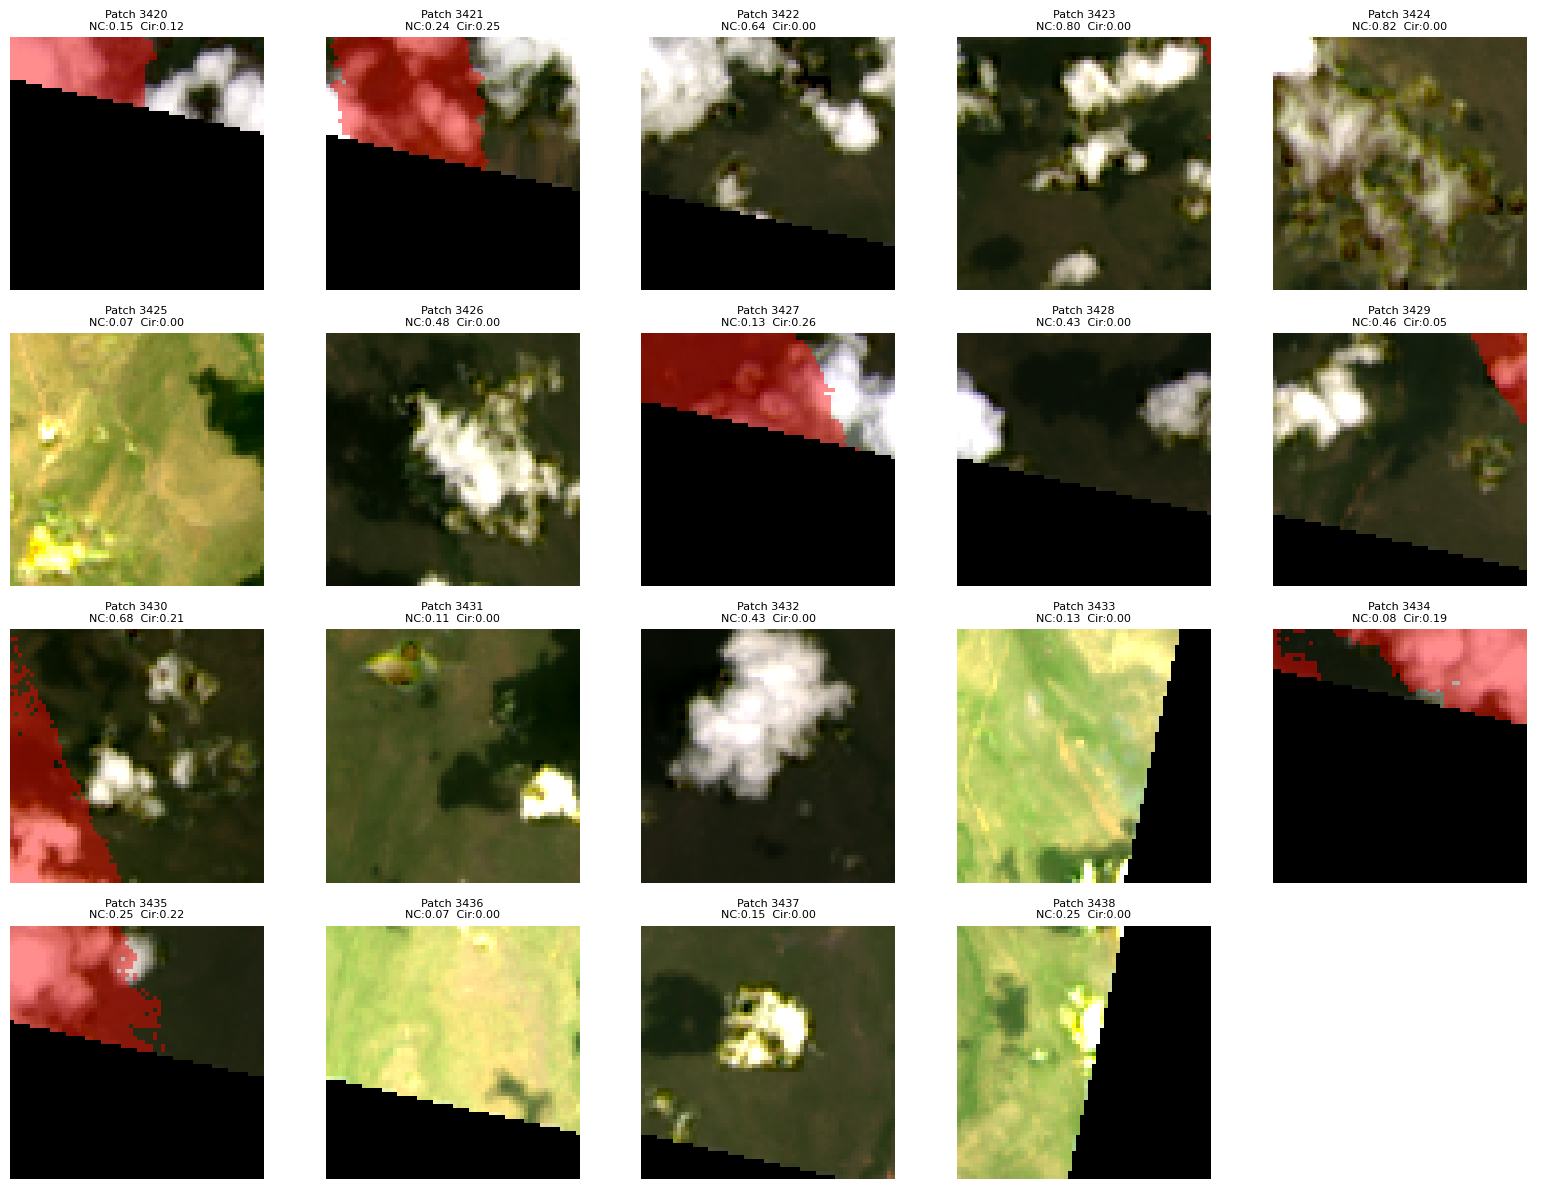


Masukkan label sesuai urutan kiri → kanan,
atas → bawah.

0 = Cumulus
1 = Stratus
2 = Ambiguous



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("=== LABELING (CUMULUS / STRATUS) ===")

# PARAMETER
BATCH_SIZE = 20

# INISIALISASI LABEL
if "labels" not in globals():

    labels = np.full(
        len(images_selected),
        -1,
        dtype=np.int8
    )

# INDEX PATCH
if "manual_idx" not in globals():

    manual_idx = np.arange(
        len(images_selected)
    )

# POSISI LABELING
if "current_pos" not in globals():

    current_pos = 0

# AMBIL BATCH
end_pos = min(
    current_pos + BATCH_SIZE,
    len(manual_idx)
)

batch = manual_idx[
    current_pos:end_pos
]

print(
    f"\nBatch {current_pos} - {end_pos}"
)

print(
"""
Label:

0 = Cumulus
1 = Stratus
2 = Ambiguous
"""
)

# VISUALISASI
fig, axes = plt.subplots(
    4,
    5,
    figsize=(16,12)
)

for ax, idx in zip(
    axes.flatten(),
    batch
):

    # RGB
    rgb = images_selected[idx][:,:,[3,2,1]]

    p2 = np.percentile(rgb,2)
    p98 = np.percentile(rgb,98)

    rgb = np.clip(
        (rgb-p2)/(p98-p2+1e-6),
        0,
        1
    )

    # RATIO
    non_ratio = np.mean(
        non_cirrus_selected[idx]
    )

    cir_ratio = np.mean(
        cirrus_selected[idx]
    )

    # TAMPILKAN RGB
    ax.imshow(rgb)

    # OVERLAY CIRRUS
    ax.imshow(
        np.ma.masked_where(
            cirrus_selected[idx]==0,
            cirrus_selected[idx]
        ),
        cmap="autumn",
        alpha=0.45
    )

    # TITLE
    ax.set_title(

        f"Patch {idx}\n"
        f"NC:{non_ratio:.2f}  "
        f"Cir:{cir_ratio:.2f}",

        fontsize=8

    )

    ax.axis("off")

# jika batch terakhir kurang dari 20
for ax in axes.flatten()[len(batch):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(
"""
Masukkan label sesuai urutan kiri → kanan,
atas → bawah.

0 = Cumulus
1 = Stratus
2 = Ambiguous
"""
)



In [ ]:
import numpy as np
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/hasil_transformer_64"

inp = input("Masukkan label : ")

vals = list(
    map(
        int,
        inp.split()
    )
)

if len(vals) != len(batch):

    print("❌ Jumlah label tidak sesuai")

else:

    for idx, label in zip(batch, vals):
        labels[idx] = label

    current_pos = end_pos

    print(f"{current_pos}/{len(manual_idx)}")
    print(f"Sisa Patch : {len(manual_idx)-current_pos}")

    # ==============================
    # AUTO CHECKPOINT
    # ==============================
    if current_pos % 500 == 0 or current_pos == len(manual_idx):

        np.save(
            "/content/drive/MyDrive/hasil_transformer_64/label_checkpoint.npy",
            labels
        )

        np.save(
            "/content/drive/MyDrive/hasil_transformer_64/progress.npy",
            np.array([current_pos])
        )

        print(f"\n💾 Checkpoint tersimpan ({current_pos} patch)")

Masukkan label : 0 0 0 0 0 2 0 0 0 0 0 0 0 2 2 0 2 0 0
3439/3439
Sisa Patch : 0

💾 Checkpoint tersimpan (3439 patch)


In [ ]:
import numpy as np

SAVE_PATH = "/content/drive/MyDrive/hasil_transformer_64/"

np.save(
    SAVE_PATH + "label_transformer_64.npy",
    labels
)

print("✔ Label berhasil disimpan")

print("\nDistribusi Label")

print(
    "Cumulus  :",
    np.sum(labels==0)
)

print(
    "Stratus  :",
    np.sum(labels==1)
)

print(
    "Ambiguous:",
    np.sum(labels==2)
)

print(
    "Belum Label:",
    np.sum(labels==-1)
)

✔ Label berhasil disimpan

Distribusi Label
Cumulus  : 2434
Stratus  : 612
Ambiguous: 393
Belum Label: 0


LOAD LABEL

In [ ]:
import numpy as np

print("=== LOAD LABEL ===")

labels = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/label_transformer_64.npy"
)

print("Shape labels:", labels.shape)

print("\n=== DISTRIBUSI LABEL ===")

class_names = [
    "Cumulus",
    "Stratus",
    "Ambiguous"
]

for i, name in enumerate(class_names):

    print(
        f"{name:10s} ({i}) :",
        np.sum(labels == i)
    )

=== LOAD LABEL ===
Shape labels: (3439,)

=== DISTRIBUSI LABEL ===
Cumulus    (0) : 2434
Stratus    (1) : 612
Ambiguous  (2) : 393


PATCH CUMULUS

Jumlah patch Cumulus: 2434


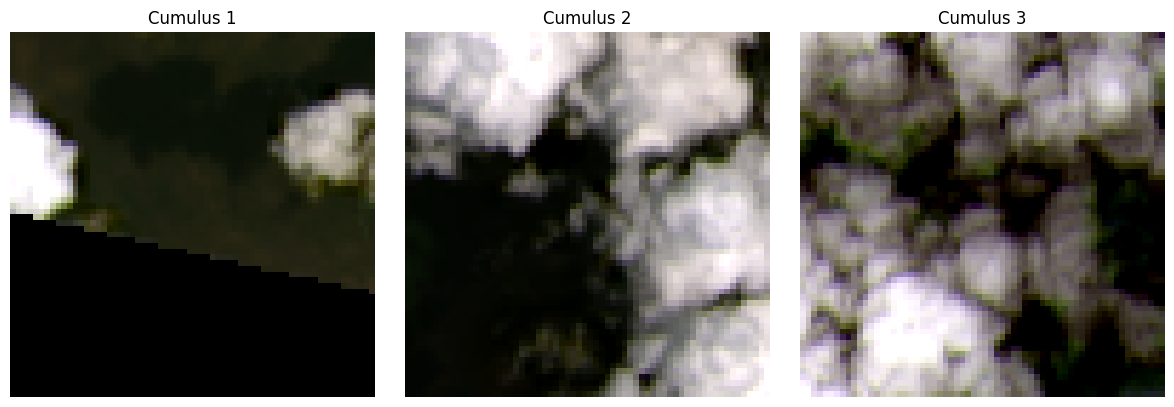

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "/content/drive/MyDrive/hasil_transformer_64"

# Load menggunakan memory mapping (hemat RAM)
images = np.load(
    f"{RESULTS_PATH}/images_selected_64.npy",
    mmap_mode="r"
)

labels = np.load(
    f"{RESULTS_PATH}/label_transformer_64.npy"
)

# Ambil seluruh patch Cumulus (label = 0)
cumulus_idx = np.where(labels == 0)[0]

print(f"Jumlah patch Cumulus: {len(cumulus_idx)}")

# Pilih 3 patch secara acak
np.random.seed(20)
selected = np.random.choice(cumulus_idx, size=3, replace=False)

plt.figure(figsize=(12,4))

for i, idx in enumerate(selected):

    # Hanya membaca SATU patch dari file
    patch = images[idx]

    # Komposit RGB Landsat 9 (B4-B3-B2)
    rgb = patch[:, :, [3, 2, 1]].astype(np.float32)

    # Contrast Stretching (2%-98%)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

    plt.subplot(1, 3, i + 1)
    plt.imshow(rgb)
    plt.title(f"Cumulus {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Jumlah patch :", len(images))
print("Jumlah label :", len(labels))

assert len(images) == len(labels), "Jumlah patch dan label tidak sama!"

Jumlah patch : 3439
Jumlah label : 3439


PATCH STRATUS

Jumlah patch : 3439
Jumlah label : 3439
Jumlah patch Stratus: 612


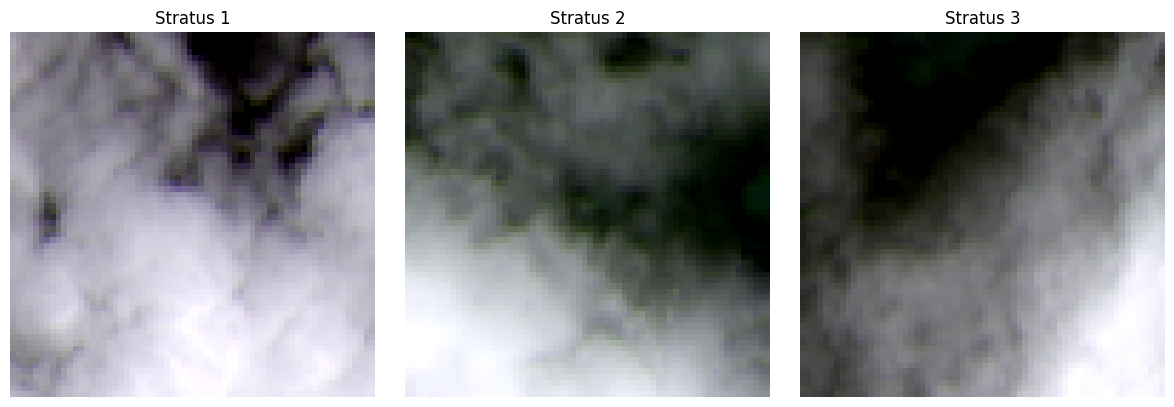

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "/content/drive/MyDrive/hasil_transformer_64"

# Load menggunakan memory mapping (hemat RAM)
images = np.load(
    f"{RESULTS_PATH}/images_selected_64.npy",
    mmap_mode="r"
)

labels = np.load(
    f"{RESULTS_PATH}/label_transformer_64.npy"
)

# Pastikan jumlah patch dan label sama
print("Jumlah patch :", len(images))
print("Jumlah label :", len(labels))
assert len(images) == len(labels), "Jumlah patch dan label tidak sama!"

# Ambil seluruh patch Stratus (label = 1)
stratus_idx = np.where(labels == 1)[0]

print(f"Jumlah patch Stratus: {len(stratus_idx)}")

# Pilih 3 patch secara acak
np.random.seed(31)
selected = np.random.choice(stratus_idx, size=3, replace=False)

plt.figure(figsize=(12,4))

for i, idx in enumerate(selected):

    # Membaca satu patch saja
    patch = images[idx]

    # Komposit RGB Landsat 9 (B4-B3-B2)
    rgb = patch[:, :, [3, 2, 1]].astype(np.float32)

    # Contrast Stretching
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

    plt.subplot(1, 3, i + 1)
    plt.imshow(rgb)
    plt.title(f"Stratus {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

PATCH AMBIGUOUS

# Section 9: Split Dataset

REMOVE AMBIGUOUS

In [ ]:
import numpy as np

print("=== REMOVE AMBIGUOUS PATCH ===")

# DISTRIBUSI SEBELUM FILTERING
print("\nDistribusi sebelum filtering")

print("Cumulus   :", np.sum(labels == 0))
print("Stratus   :", np.sum(labels == 1))
print("Ambiguous :", np.sum(labels == 2))

# AMBIL PATCH YANG BUKAN AMBIGUOUS
valid_idx = np.where(
    labels != 2
)[0]

print("\nPatch yang digunakan :", len(valid_idx))

# FILTER SEMUA DATA
images_final = images_selected[
    valid_idx
]

gan_final = gan_selected[
    valid_idx
]

cirrus_final = cirrus_selected[
    valid_idx
]

non_cirrus_final = non_cirrus_selected[
    valid_idx
]

coords_final = coords_selected[
    valid_idx
]

labels_final = labels[
    valid_idx
]

# INFORMASI DATASET
print("\n=== HASIL FILTER ===")

print("Image       :", images_final.shape)
print("GAN         :", gan_final.shape)
print("Cirrus      :", cirrus_final.shape)
print("Non-Cirrus  :", non_cirrus_final.shape)
print("Coordinate  :", coords_final.shape)
print("Label       :", labels_final.shape)

# DISTRIBUSI SESUDAH FILTERING
print("\nDistribusi sesudah filtering")

print(
    "Cumulus :",
    np.sum(labels_final == 0)
)

print(
    "Stratus :",
    np.sum(labels_final == 1)
)

# SIMPAN DATASET
SAVE_PATH = "/content/drive/MyDrive/hasil_transformer_64/"

np.save(
    SAVE_PATH + "images_final_64.npy",
    images_final
)

np.save(
    SAVE_PATH + "gan_final_64.npy",
    gan_final
)

np.save(
    SAVE_PATH + "cirrus_final_64.npy",
    cirrus_final
)

np.save(
    SAVE_PATH + "non_cirrus_final_64.npy",
    non_cirrus_final
)

np.save(
    SAVE_PATH + "coords_final_64.npy",
    coords_final
)

np.save(
    SAVE_PATH + "labels_final_64.npy",
    labels_final
)

print("\n✔ Dataset tanpa Ambiguous berhasil disimpan")

=== REMOVE AMBIGUOUS PATCH ===

Distribusi sebelum filtering
Cumulus   : 2434
Stratus   : 612
Ambiguous : 393

Patch yang digunakan : 3046

=== HASIL FILTER ===
Image       : (3046, 64, 64, 12)
GAN         : (3046, 64, 64)
Cirrus      : (3046, 64, 64)
Non-Cirrus  : (3046, 64, 64)
Coordinate  : (3046, 2)
Label       : (3046,)

Distribusi sesudah filtering
Cumulus : 2434
Stratus : 612

✔ Dataset tanpa Ambiguous berhasil disimpan


SPLIT TRAINING TESTING

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

print("=== BALANCE DATASET + TRAIN TEST SPLIT ===")

# RANDOM SEED
np.random.seed(42)

# DISTRIBUSI AWAL
print("\n=== DISTRIBUSI AWAL ===")

n_cumulus = np.sum(labels_final == 0)
n_stratus = np.sum(labels_final == 1)

print("Cumulus :", n_cumulus)
print("Stratus :", n_stratus)

# INDEX MASING-MASING KELAS
idx_cumulus = np.where(labels_final == 0)[0]
idx_stratus = np.where(labels_final == 1)[0]

# BALANCE (UNDERSAMPLING)
min_count = min(
    len(idx_cumulus),
    len(idx_stratus)
)

print("\nJumlah balance per kelas :", min_count)

np.random.shuffle(idx_cumulus)
np.random.shuffle(idx_stratus)

idx_cumulus = idx_cumulus[:min_count]
idx_stratus = idx_stratus[:min_count]

balanced_idx = np.concatenate([
    idx_cumulus,
    idx_stratus
])

np.random.shuffle(balanced_idx)

# DATA BALANCE
images_balance = images_final[balanced_idx]

gan_balance = gan_final[balanced_idx]

cirrus_balance = cirrus_final[balanced_idx]

non_cirrus_balance = non_cirrus_final[balanced_idx]

coords_balance = coords_final[balanced_idx]

labels_balance = labels_final[balanced_idx]

print("\n=== DATASET BALANCE ===")

print("Image      :", images_balance.shape)
print("GAN        :", gan_balance.shape)
print("Cirrus     :", cirrus_balance.shape)
print("NonCirrus  :", non_cirrus_balance.shape)
print("Coordinate :", coords_balance.shape)
print("Label      :", labels_balance.shape)

print("\nDistribusi Balance")

print("Cumulus :", np.sum(labels_balance == 0))
print("Stratus :", np.sum(labels_balance == 1))

# TRAIN TEST SPLIT
train_idx, test_idx = train_test_split(

    np.arange(len(labels_balance)),

    test_size=0.30,

    random_state=42,

    stratify=labels_balance

)

# DATA TRAIN
x_train = images_balance[train_idx]

y_train = labels_balance[train_idx]

# DATA TEST
x_test = images_balance[test_idx]

y_test = labels_balance[test_idx]

# INFORMASI
print("\n=== HASIL SPLIT ===")

print("Train :", x_train.shape)
print("Test  :", x_test.shape)

print("\nDistribusi TRAIN")

print(
    "Cumulus :",
    np.sum(y_train == 0)
)

print(
    "Stratus :",
    np.sum(y_train == 1)
)

print("\nDistribusi TEST")

print(
    "Cumulus :",
    np.sum(y_test == 0)
)

print(
    "Stratus :",
    np.sum(y_test == 1)
)

# SIMPAN
SAVE_PATH = "/content/drive/MyDrive/hasil_transformer_64/"

# Dataset
np.save(
    SAVE_PATH + "images_balance_64.npy",
    images_balance
)

np.save(
    SAVE_PATH + "gan_balance_64.npy",
    gan_balance
)

np.save(
    SAVE_PATH + "cirrus_balance_64.npy",
    cirrus_balance
)

np.save(
    SAVE_PATH + "non_cirrus_balance_64.npy",
    non_cirrus_balance
)

np.save(
    SAVE_PATH + "coords_balance_64.npy",
    coords_balance
)

np.save(
    SAVE_PATH + "labels_balance_64.npy",
    labels_balance
)

# Split Index
np.save(
    SAVE_PATH + "train_idx_64.npy",
    train_idx
)

np.save(
    SAVE_PATH + "test_idx_64.npy",
    test_idx
)

print("\n✔ Dataset balance berhasil disimpan")
print("✔ train_idx_64.npy berhasil disimpan")
print("✔ test_idx_64.npy berhasil disimpan")

=== BALANCE DATASET + TRAIN TEST SPLIT ===

=== DISTRIBUSI AWAL ===
Cumulus : 2434
Stratus : 612

Jumlah balance per kelas : 612

=== DATASET BALANCE ===
Image      : (1224, 64, 64, 12)
GAN        : (1224, 64, 64)
Cirrus     : (1224, 64, 64)
NonCirrus  : (1224, 64, 64)
Coordinate : (1224, 2)
Label      : (1224,)

Distribusi Balance
Cumulus : 612
Stratus : 612

=== HASIL SPLIT ===
Train : (856, 64, 64, 12)
Test  : (368, 64, 64, 12)

Distribusi TRAIN
Cumulus : 428
Stratus : 428

Distribusi TEST
Cumulus : 184
Stratus : 184

✔ Dataset balance berhasil disimpan
✔ train_idx_64.npy berhasil disimpan
✔ test_idx_64.npy berhasil disimpan


LOAD DATA SPLIT BALANCE

In [ ]:
import numpy as np

print("=== LOAD BALANCED DATASET ===")

SAVE_PATH = "/content/drive/MyDrive/hasil_transformer_64/"

# LOAD DATA
images = np.load(
    SAVE_PATH + "images_balance_64.npy"
)

labels = np.load(
    SAVE_PATH + "labels_balance_64.npy"
)

train_idx = np.load(
    SAVE_PATH + "train_idx_64.npy"
)

test_idx = np.load(
    SAVE_PATH + "test_idx_64.npy"
)

# INFORMASI DATASET
print("\n=== DATASET ===")

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Train Index  :", train_idx.shape)
print("Test Index   :", test_idx.shape)

# DISTRIBUSI LABEL
print("\n=== DISTRIBUSI DATASET ===")

class_names = {
    0: "Cumulus",
    1: "Stratus"
}

for label, name in class_names.items():

    print(
        f"{name:10s}: {np.sum(labels == label)}"
    )

# DISTRIBUSI TRAIN
print("\n=== DISTRIBUSI TRAIN ===")

for label, name in class_names.items():

    print(
        f"{name:10s}: {np.sum(labels[train_idx] == label)}"
    )

# DISTRIBUSI TEST
print("\n=== DISTRIBUSI TEST ===")

for label, name in class_names.items():

    print(
        f"{name:10s}: {np.sum(labels[test_idx] == label)}"
    )

# CEK LABEL
print("\nUnique Labels :", np.unique(labels))

=== LOAD BALANCED DATASET ===

=== DATASET ===
Images Shape : (1224, 64, 64, 12)
Labels Shape : (1224,)
Train Index  : (856,)
Test Index   : (368,)

=== DISTRIBUSI DATASET ===
Cumulus   : 612
Stratus   : 612

=== DISTRIBUSI TRAIN ===
Cumulus   : 428
Stratus   : 428

=== DISTRIBUSI TEST ===
Cumulus   : 184
Stratus   : 184

Unique Labels : [0 1]


# Section 10: Model Transformer

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=== MEMBANGUN MODEL TRANSFORMER FINAL ===")

# PARAMETER
IMG_SIZE = 64
CHANNELS = 12

NUM_CLASSES = 2

PATCH_SIZE = 8

PROJECTION_DIM = 64

NUM_HEADS = 4

TRANSFORMER_LAYERS = 4

MLP_HEAD_UNITS = [128, 64]

# DATA AUGMENTATION
data_augmentation = keras.Sequential([

    layers.RandomFlip(
        "horizontal_and_vertical"
    ),

    layers.RandomRotation(
        0.1
    ),

    layers.RandomZoom(
        0.1
    ),

])

# PATCH LAYER
class Patches(layers.Layer):

    def __init__(self, patch_size=8, **kwargs):

        super().__init__(**kwargs)

        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            rates=[1,1,1,1],

            padding="VALID"

        )

        patch_dims = patches.shape[-1]

        patches = tf.reshape(

            patches,

            [
                batch_size,
                -1,
                patch_dims
            ]

        )

        return patches

    def get_config(self):

        config = super().get_config()

        config.update({
            "patch_size": self.patch_size
        })

        return config

# PATCH ENCODER
class PatchEncoder(layers.Layer):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.num_patches = num_patches

        self.projection_dim = projection_dim

        self.projection = layers.Dense(
            projection_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):

        positions = tf.range(
            start=0,
            limit=self.num_patches,
            delta=1
        )

        encoded = (
            self.projection(patch)
            +
            self.position_embedding(positions)
        )

        return encoded

    def get_config(self):

        config = super().get_config()

        config.update({

            "num_patches":
            self.num_patches,

            "projection_dim":
            self.projection_dim

        })

        return config

# MLP BLOCK
def mlp(
    x,
    hidden_units,
    dropout_rate
):

    for units in hidden_units:

        x = layers.Dense(
            units,
            activation=tf.nn.gelu
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

    return x

# BUILD MODEL
def create_transformer_model():

    inputs = layers.Input(

        shape=(
            IMG_SIZE,
            IMG_SIZE,
            CHANNELS
        )

    )

    # AUGMENTATION
    augmented = data_augmentation(
        inputs
    )

    # PATCH EXTRACTION
    patches = Patches(
        PATCH_SIZE
    )(augmented)

    num_patches = (
        IMG_SIZE // PATCH_SIZE
    ) ** 2

    # PATCH ENCODING
    encoded_patches = PatchEncoder(
        num_patches,
        PROJECTION_DIM
    )(patches)

    # TRANSFORMER BLOCK
    for _ in range(
        TRANSFORMER_LAYERS
    ):

        x1 = layers.LayerNormalization(
            epsilon=1e-6
        )(encoded_patches)

        attention_output = layers.MultiHeadAttention(

            num_heads=NUM_HEADS,

            key_dim=PROJECTION_DIM,

            dropout=0.1

        )(
            x1,
            x1
        )

        x2 = layers.Add()([
            attention_output,
            encoded_patches
        ])

        x3 = layers.LayerNormalization(
            epsilon=1e-6
        )(x2)

        x3 = mlp(

            x3,

            hidden_units=[
                PROJECTION_DIM * 2,
                PROJECTION_DIM
            ],

            dropout_rate=0.1

        )

        encoded_patches = layers.Add()([
            x3,
            x2
        ])

    # CLASSIFICATION HEAD
    representation = layers.LayerNormalization(
        epsilon=1e-6
    )(encoded_patches)

    representation = layers.GlobalAveragePooling1D()(
        representation
    )

    representation = layers.Dropout(
        0.5
    )(representation)

    features = mlp(

        representation,

        hidden_units=MLP_HEAD_UNITS,

        dropout_rate=0.3

    )

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax"

    )(features)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    return model

# CREATE MODEL
model = create_transformer_model()

# COMPILE
optimizer = keras.optimizers.AdamW(

    learning_rate=1e-4,

    weight_decay=1e-4

)

model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

model.summary()

print("\n🔥 MODEL TRANSFORMER SIAP")

=== MEMBANGUN MODEL TRANSFORMER FINAL ===


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 64,    │          0 │ input_layer[0][0] │
│ (Sequential)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     53,312 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_3[0][0]   

 Total params: 402,946 (1.54 MB)

 Trainable params: 402,946 (1.54 MB)

 Non-trainable params: 0 (0.00 B)


🔥 MODEL TRANSFORMER SIAP


# Section 11: Training

In [ ]:
import numpy as np
import tensorflow as tf

from tqdm.keras import TqdmCallback

print("=== TRAINING TRANSFORMER ===")

# LOAD DATASET
images = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/images_balance_64.npy"
)

labels = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/labels_balance_64.npy"
)

train_idx = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/train_idx_64.npy"
)

test_idx = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/test_idx_64.npy"
)

# AMBIL DATA TRAIN DAN TEST
x_train = images[train_idx]

y_train = labels[train_idx]

x_test = images[test_idx]

y_test = labels[test_idx]

# INFO DATASET
print("\n========== DATASET ==========")

print("Train :", x_train.shape)
print("Test  :", x_test.shape)

print("\nDistribusi TRAIN")

print(
    "Cumulus :",
    np.sum(y_train == 0)
)

print(
    "Stratus :",
    np.sum(y_train == 1)
)

print("\nDistribusi TEST")

print(
    "Cumulus :",
    np.sum(y_test == 0)
)

print(
    "Stratus :",
    np.sum(y_test == 1)
)

x_train = x_train.astype(np.float32)

x_test = x_test.astype(np.float32)

# CALLBACK
checkpoint_path = (
    "/content/drive/MyDrive/"
    "hasil_transformer_64/"
    "model_transformer_best_64.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(

        checkpoint_path,

        monitor="val_accuracy",

        save_best_only=True,

        verbose=1

    ),

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=10,

        restore_best_weights=True

    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=5,

        verbose=1

    ),

    TqdmCallback(verbose=1)

]

# TRAINING
print("\n🔥 MULAI TRAINING\n")

history = model.fit(

    x_train,

    y_train,

    validation_data=(

        x_test,

        y_test

    ),

    epochs=100,

    batch_size=8,

    callbacks=callbacks,

    verbose=0

)

print("\n✔ TRAINING SELESAI")

# SAVE MODEL
model.save(

    "/content/drive/MyDrive/"
    "hasil_transformer_64/"
    "model_transformer_final_64.keras"

)

# EVALUASI
loss, acc = model.evaluate(

    x_test,

    y_test,

    verbose=0

)

print(

    f"\n🔥 TEST ACCURACY : {acc*100:.2f}%"

)

print(

    f"TEST LOSS : {loss:.4f}"

)

=== TRAINING TRANSFORMER ===

========== DATASET ==========
Train : (856, 64, 64, 12)
Test  : (368, 64, 64, 12)

Distribusi TRAIN
Cumulus : 428
Stratus : 428

Distribusi TEST
Cumulus : 184
Stratus : 184


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


🔥 MULAI TRAINING


Epoch 1: val_accuracy improved from None to 0.72554, saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 1: finished saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 2: val_accuracy improved from 0.72554 to 0.72826, saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 2: finished saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 3: val_accuracy improved from 0.72826 to 0.73913, saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 3: finished saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 4: val_accuracy improved from 0.73913 to 0.74457, saving model to /content/drive/MyDrive/hasil_transformer_64/model_transformer_best_64.keras

Epoch 4: finished saving model to /content/drive/MyDri

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "/content/drive/MyDrive/hasil_transformer_64/history_transformer.csv",
    index=False
)

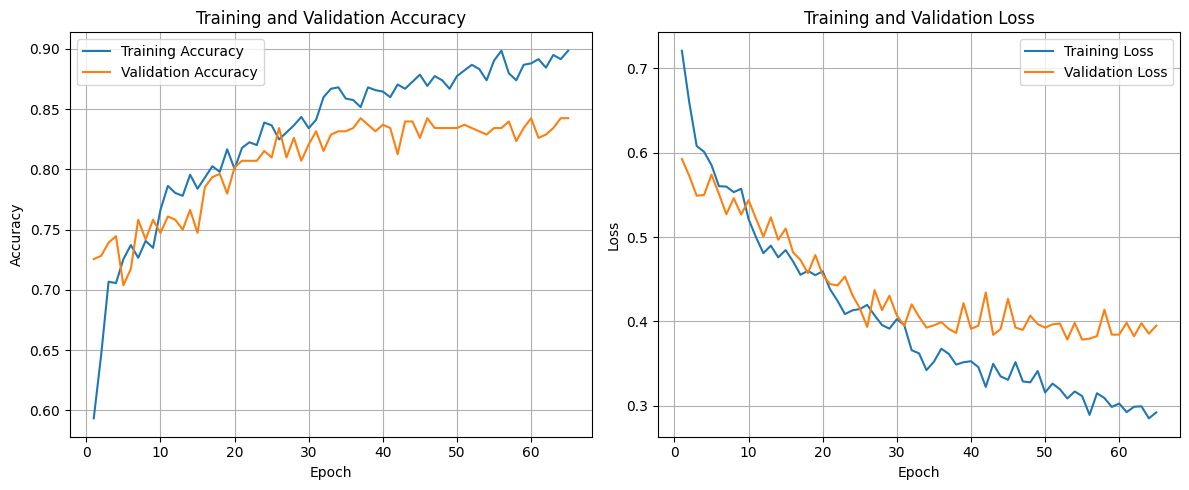

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.read_csv(
    "/content/drive/MyDrive/hasil_transformer_64/history_transformer.csv"
)

epochs = range(1, len(history_df)+1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(
    epochs,
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(
    epochs,
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Section 12: Testing

=== TESTING TRANSFORMER ===
✔ Model berhasil di-load

Jumlah data test : 368
Cumulus : 184
Stratus : 184

🔥 TEST ACCURACY : 83.42%
TEST LOSS : 0.3784
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

     Cumulus       0.94      0.72      0.81       184
     Stratus       0.77      0.95      0.85       184

    accuracy                           0.83       368
   macro avg       0.85      0.83      0.83       368
weighted avg       0.85      0.83      0.83       368



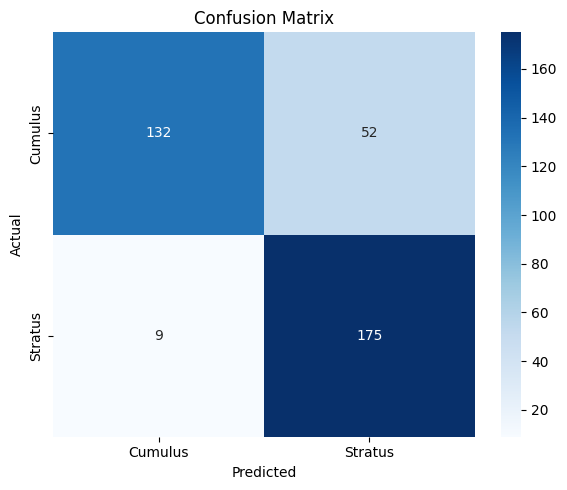

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.utils import custom_object_scope

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

print("=== TESTING TRANSFORMER ===")

# CUSTOM LAYER
class Patches(layers.Layer):

    def __init__(self, patch_size=8, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1,self.patch_size,self.patch_size,1],
            strides=[1,self.patch_size,self.patch_size,1],
            rates=[1,1,1,1],
            padding="VALID"
        )

        patch_dims = patches.shape[-1]

        patches = tf.reshape(
            patches,
            [batch_size,-1,patch_dims]
        )

        return patches

    def get_config(self):

        config = super().get_config()

        config.update({
            "patch_size": self.patch_size
        })

        return config


class PatchEncoder(layers.Layer):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(
            projection_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):

        positions = tf.range(
            start=0,
            limit=self.num_patches,
            delta=1
        )

        return (
            self.projection(patch)
            +
            self.position_embedding(positions)
        )

    def get_config(self):

        config = super().get_config()

        config.update({

            "num_patches": self.num_patches,

            "projection_dim": self.projection_dim

        })

        return config

# LOAD MODEL
with custom_object_scope({

    "Patches": Patches,

    "PatchEncoder": PatchEncoder

}):

    model = tf.keras.models.load_model(

        "/content/drive/MyDrive/hasil_transformer_64/model_transformer_final_64.keras",

        compile=False

    )

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("✔ Model berhasil di-load")

# LOAD DATASET
images = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/images_balance_64.npy"
)

labels = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/labels_balance_64.npy"
)

test_idx = np.load(
    "/content/drive/MyDrive/hasil_transformer_64/test_idx_64.npy"
)

# DATA TEST
x_test = images[test_idx]

y_test = labels[test_idx]

print("\nJumlah data test :", len(x_test))

print(
    "Cumulus :",
    np.sum(y_test == 0)
)

print(
    "Stratus :",
    np.sum(y_test == 1)
)

# NORMALISASI
x_test = x_test.astype(np.float32)

# EVALUASI
loss, acc = model.evaluate(

    x_test,

    y_test,

    verbose=0

)

print(
    f"\n🔥 TEST ACCURACY : {acc*100:.2f}%"
)

print(
    f"TEST LOSS : {loss:.4f}"
)

# PREDIKSI
pred = model.predict(

    x_test,

    batch_size=8,

    verbose=1

)

y_pred = np.argmax(

    pred,

    axis=1

)

# CLASSIFICATION REPORT
print("\n========== CLASSIFICATION REPORT ==========\n")

print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Cumulus",

            "Stratus"

        ]

    )

)

# CONFUSION MATRIX
cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[

        "Cumulus",

        "Stratus"

    ],

    yticklabels=[

        "Cumulus",

        "Stratus"

    ]

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# Section 13: Visualisasi

LOAD MODEL TRANSFORMER

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import custom_object_scope

print("=== LOAD TRANSFORMER MODEL ===")

# PATCH LAYER
class Patches(layers.Layer):

    def __init__(self, patch_size=8, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID"
        )

        patch_dims = patches.shape[-1]

        patches = tf.reshape(
            patches,
            [batch_size, -1, patch_dims]
        )

        return patches

    def get_config(self):

        config = super().get_config()

        config.update({
            "patch_size": self.patch_size
        })

        return config

# PATCH ENCODER
class PatchEncoder(layers.Layer):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(
            projection_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):

        positions = tf.range(
            start=0,
            limit=self.num_patches,
            delta=1
        )

        return (
            self.projection(patch)
            +
            self.position_embedding(positions)
        )

    def get_config(self):

        config = super().get_config()

        config.update({

            "num_patches": self.num_patches,

            "projection_dim": self.projection_dim

        })

        return config

# LOAD MODEL
MODEL_PATH = (
    "/content/drive/MyDrive/"
    "hasil_transformer_64/"
    "model_transformer_final_64.keras"
)

with custom_object_scope({

    "Patches": Patches,

    "PatchEncoder": PatchEncoder

}):

    model = tf.keras.models.load_model(
        MODEL_PATH,
        compile=False
    )

# COMPILE
model.compile(

    optimizer=tf.keras.optimizers.Adam(),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("✔ Model berhasil di-load")

model.summary()

=== LOAD TRANSFORMER MODEL ===
✔ Model berhasil di-load


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 64,    │          0 │ input_layer[0][0] │
│ (Sequential)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     53,312 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_3[0][0]   

 Total params: 402,946 (1.54 MB)

 Trainable params: 402,946 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import gc

print("=== LOW MEMORY TRANSFORMER INFERENCE ===")

NON_CIRRUS_THRESHOLD = 0.05
CIRRUS_THRESHOLD = 0.40

# HITUNG RASIO
non_cirrus_ratio = np.mean(
    non_cirrus_patch,
    axis=(1,2)
)

cirrus_ratio = np.mean(
    cirrus_patch,
    axis=(1,2)
)

# PATCH YANG AKAN DIPREDIKSI TRANSFORMER
cloud_idx = np.where(

    (non_cirrus_ratio >= NON_CIRRUS_THRESHOLD) &
    (cirrus_ratio <= CIRRUS_THRESHOLD)

)[0]

print("Total Patch :", len(images_patch))
print("Predicted Patch :", len(cloud_idx))
print("Ignored Patch :", len(images_patch)-len(cloud_idx))

# OUTPUT PREDIKSI
pred_labels = np.zeros(
    len(cloud_idx),
    dtype=np.uint8
)

# LOW MEMORY INFERENCE
BATCH_SIZE = 16

for start in range(0, len(cloud_idx), BATCH_SIZE):

    end = min(start+BATCH_SIZE, len(cloud_idx))

    idx_batch = cloud_idx[start:end]

    batch = images_patch[idx_batch].astype(np.float32)

    pred = model.predict(
        batch,
        verbose=0
    )

    pred_labels[start:end] = np.argmax(
        pred,
        axis=1
    )

    del batch
    del pred

    gc.collect()

print("✔ Inference selesai")

=== LOW MEMORY TRANSFORMER INFERENCE ===
Total Patch : 14399
Predicted Patch : 3439
Ignored Patch : 10960
✔ Inference selesai


In [ ]:
import numpy as np

print("=== RECONSTRUCT CLOUD CLASSIFICATION MAP ===")

IMAGE_PATCH_SIZE = images_patch.shape[1]

# CLASS (0 = Non-cloud, 1 = Cirrus, 2 = Cumulus, 3 = Stratus, 255 = Unknown Cloud)
class_map = np.zeros(

    (CROP_HEIGHT, CROP_WIDTH),

    dtype=np.uint8

)

class_map[cirrus_full == 1] = 1

ignored_idx = np.where(

    (non_cirrus_ratio < NON_CIRRUS_THRESHOLD) |
    (cirrus_ratio > CIRRUS_THRESHOLD)

)[0]

print("Ignored Patch :", len(ignored_idx))

for patch_id in ignored_idx:

    if np.sum(non_cirrus_patch[patch_id]) == 0:
        continue

    y, x = patch_coords[patch_id]

    block = class_map[
        y:y+IMAGE_PATCH_SIZE,
        x:x+IMAGE_PATCH_SIZE
    ]

    mask = non_cirrus_patch[
        patch_id
    ].astype(bool)

    block[mask] = 255

# HASIL TRANSFORMER
for n, patch_id in enumerate(cloud_idx):

    y, x = patch_coords[patch_id]

    block = class_map[
        y:y+IMAGE_PATCH_SIZE,
        x:x+IMAGE_PATCH_SIZE
    ]

    mask = non_cirrus_patch[
        patch_id
    ].astype(bool)

    if pred_labels[n] == 0:

        block[mask] = 2

    else:

        block[mask] = 3

print("✔ Reconstruction selesai")

print("Unique :", np.unique(class_map))

=== RECONSTRUCT CLOUD CLASSIFICATION MAP ===
Ignored Patch : 10960
✔ Reconstruction selesai
Unique : [  0   1   2   3 255]


In [ ]:
import numpy as np

print("=== PIXEL STATISTICS ===")

# KELAS
classes = {
    0: "Non-cloud",
    1: "Cirrus",
    2: "Cumulus",
    3: "Stratus",
    255: "Unknown"
}

total_pixel = class_map.size

print(f"Total Pixel : {total_pixel:,}\n")

for value, name in classes.items():

    count = np.sum(class_map == value)

    percentage = count / total_pixel * 100

    print(
        f"{name:12s}: "
        f"{count:,} pixel "
        f"({percentage:.2f}%)"
    )

# VALIDASI
classified = np.sum(class_map != 0)

print("\n==============================")
print("Total Cloud Pixel :", classified)
print("Non-cloud Pixel   :", np.sum(class_map == 0))
print("==============================")

=== PIXEL STATISTICS ===
Total Pixel : 58,978,304

Non-cloud   : 25,475,413 pixel (43.19%)
Cirrus      : 23,092,024 pixel (39.15%)
Cumulus     : 5,253,263 pixel (8.91%)
Stratus     : 4,603,127 pixel (7.80%)
Unknown     : 554,477 pixel (0.94%)

Total Cloud Pixel : 33502891
Non-cloud Pixel   : 25475413


=== VISUALISASI CLOUD CLASSIFICATION MAP ===


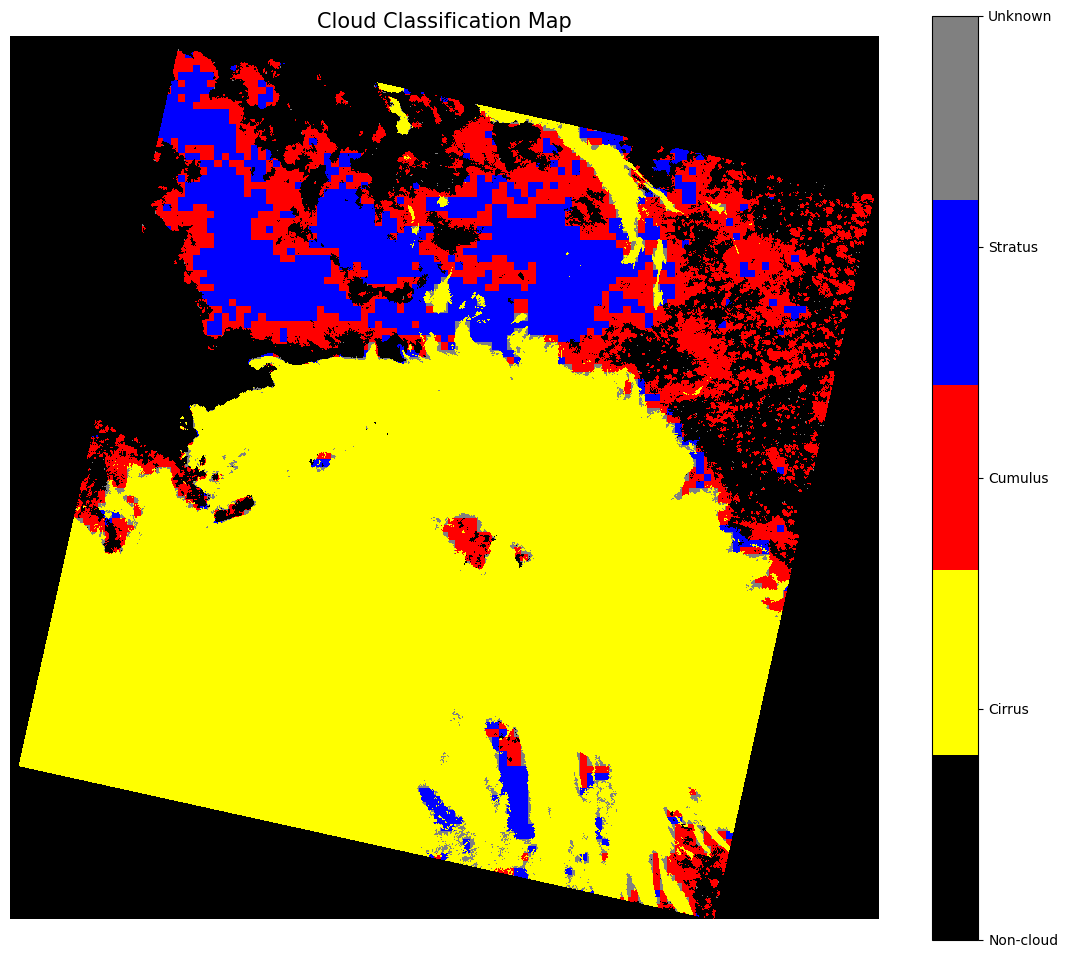

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("=== VISUALISASI CLOUD CLASSIFICATION MAP ===")
display_map = class_map.copy()

display_map[
    display_map == 255
] = 4

# COLOR MAP
cmap = ListedColormap([
    "black",      # 0 Non-cloud
    "yellow",     # 1 Cirrus
    "red",        # 2 Cumulus
    "blue",       # 3 Stratus
    "gray"        # 4 Unknown
])

# VISUALISASI
plt.figure(figsize=(14,12))

img = plt.imshow(
    display_map,
    cmap=cmap,
    interpolation="nearest"
)

cbar = plt.colorbar(
    img,
    ticks=[0,1,2,3,4]
)

cbar.ax.set_yticklabels([
    "Non-cloud",
    "Cirrus",
    "Cumulus",
    "Stratus",
    "Unknown"
])

plt.title(
    "Cloud Classification Map",
    fontsize=15
)

plt.axis("off")

plt.show()